<a href="https://colab.research.google.com/github/rupesh0424/ML/blob/main/ML_EXP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("Library Versions")
print("-" * 40)
print(f"Pandas         : {pd.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")

Library Versions
----------------------------------------
Pandas         : 2.2.2
NumPy          : 2.0.2
Scikit-learn   : 1.6.1
Matplotlib     : 3.10.0
Seaborn        : 0.13.2


In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
from pandas import read_csv
df = read_csv("placement_predict_50k Dataset.csv")

In [ ]:
df.tail(5)

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
30813,30814,Male,Chennai,Tier2,CS,Embedded,No,No,9.19,9.15,...,1.0,74.9,3.9,81.8,81.3,1.0,High,1.0,0.0,26.00
30814,30815,Female,Pune,Tier3,ECE,AI,Yes,No,4.00,4.00,...,0.0,46.2,1.6,31.0,NaN,0.0,Low,0.0,0.0,0.00
30815,30816,Female,Kolkata,Tier1,CS,DataScience,No,No,9.82,9.80,...,1.0,84.4,3.7,75.2,68.6,1.0,High,1.0,0.0,25.13
30816,30817,Female,Chennai,Tier3,Mechanical,AI,No,No,5.30,5.19,...,1.0,75.3,3.1,40.8,56.8,0.0,Low,0.0,0.0,0.00
30817,30818,Female,Chennai,Tier2,ECE,Networking,No,Yes,7.33,6.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(30818, 32)

In [ ]:
rows, columns=df.shape
rows

30818

In [ ]:
df['StudentID']

,StudentID
0,1
1,2
2,3
3,4
4,5
...,...
30813,30814
30814,30815
30815,30816
30816,30817


In [ ]:
df.columns

Index(['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream',
       'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1',
       'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6',
       'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus',
       'IsAnomaly', 'Salary Package'],
      dtype='object')

In [ ]:
df.dtypes

,0
StudentID,int64
Gender,object
City,object
CollegeTier,object
Stream,object
Specialisation,object
Hostel,object
HistoryOfBacklogs,object
SGPA_Sem1,float64
SGPA_Sem2,float64


In [ ]:
df.dtypes.value_counts()

,count
float64,23
object,8
int64,1


In [ ]:
# Step 1: Checking Missing Values
#Missing values are one of the most common problems in real-world datasets.
#Before training a Machine Learning model, we must identify columns containing missing values.
# df.isnull().sum()

missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_data

,Missing Values,Percentage
StudentID,0,0.000000
Gender,0,0.000000
City,0,0.000000
CollegeTier,0,0.000000
Stream,0,0.000000
Specialisation,0,0.000000
Hostel,0,0.000000
HistoryOfBacklogs,0,0.000000
SGPA_Sem1,0,0.000000
SGPA_Sem2,0,0.000000


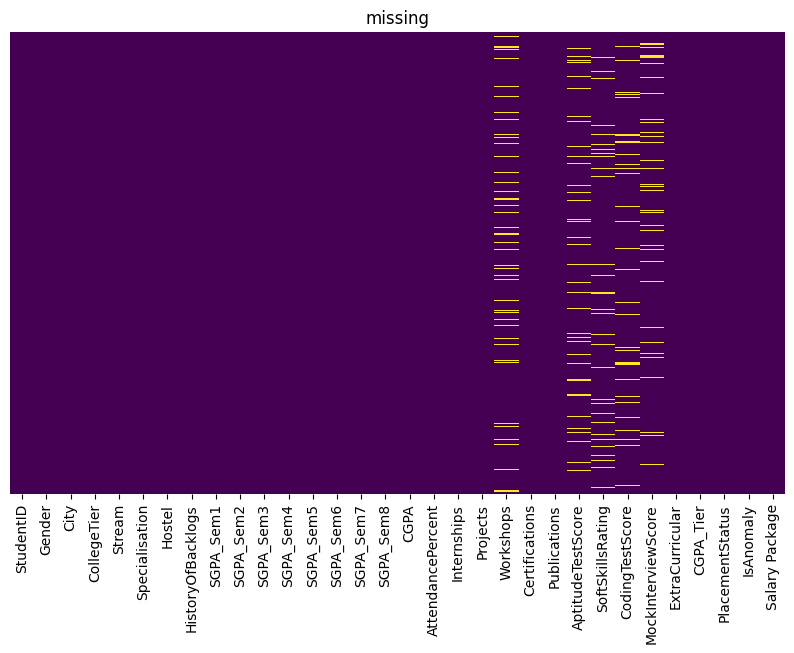

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# cbar=False hides the color bar; yticklabels=False hides row numbers for cleaner v
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("missing")
plt.show()

In [ ]:
#Keeps the first occurrence and marks subsequent duplicates as True(if any)
duplicate_rows = df[df.duplicated()]
print(f"Total duplicate rows detected: {len(duplicate_rows)}")
print(duplicate_rows)
print("-" * 40)

Total duplicate rows detected: 0
Empty DataFrame
Columns: [StudentID, Gender, City, CollegeTier, Stream, Specialisation, Hostel, HistoryOfBacklogs, SGPA_Sem1, SGPA_Sem2, SGPA_Sem3, SGPA_Sem4, SGPA_Sem5, SGPA_Sem6, SGPA_Sem7, SGPA_Sem8, CGPA, AttendancePercent, Internships, Projects, Workshops, Certifications, Publications, AptitudeTestScore, SoftSkillsRating, CodingTestScore, MockInterviewScore, ExtraCurricular, CGPA_Tier, PlacementStatus, IsAnomaly, Salary Package]
Index: []

[0 rows x 32 columns]
----------------------------------------


In [ ]:
#display rows where null values are present if any
df[df['AptitudeTestScore'].isnull()]

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
7,8,Male,Delhi,Tier2,Mechanical,Embedded,Yes,No,5.87,5.64,...,0.0,NaN,2.0,35.2,27.8,0.0,Low,0.0,0.0,0.00
13,14,Male,Delhi,Tier1,CS,AI,No,No,10.00,10.00,...,1.0,NaN,NaN,87.9,86.8,1.0,High,1.0,0.0,18.11
18,19,Male,Bangalore,Tier2,Mechanical,Embedded,No,No,6.97,6.53,...,0.0,NaN,1.3,57.9,56.6,0.0,Mid,0.0,0.0,0.00
29,30,Female,Pune,Tier2,Civil,Networking,Yes,No,9.94,9.85,...,2.0,NaN,4.8,60.3,89.3,1.0,High,1.0,0.0,25.15
33,34,Male,Kochi,Tier3,Civil,AI,Yes,No,4.52,4.06,...,1.0,NaN,2.1,27.4,34.6,1.0,Low,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30749,30750,Male,Bangalore,Tier1,ECE,Networking,Yes,No,9.43,8.94,...,2.0,NaN,3.5,NaN,67.6,1.0,High,1.0,0.0,18.03
30775,30776,Male,Bangalore,Tier2,ECE,Networking,Yes,No,7.78,7.51,...,1.0,NaN,2.0,NaN,41.0,1.0,Mid,1.0,0.0,12.24
30783,30784,Female,Kolkata,Tier1,ECE,Embedded,No,No,7.18,7.65,...,2.0,NaN,5.0,80.8,85.4,0.0,Mid,1.0,0.0,8.75
30797,30798,Female,Mumbai,Tier2,ECE,Embedded,No,Yes,7.50,7.59,...,1.0,NaN,NaN,61.9,50.0,1.0,Mid,0.0,0.0,0.00


In [ ]:
#  Checking for Duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
#Remove Duplicates
df = df.drop_duplicates()

In [ ]:
df.shape

(30818, 32)

In [ ]:
df.describe()

,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly,Salary Package
count,30818.000000,30818.000000,30818.000000,30818.000000,30818.000000,30818.000000,30817.000000,30817.000000,30817.000000,30817.000000,...,30817.000000,30817.000000,28332.000000,28649.000000,28976.000000,27738.000000,30817.000000,30817.000000,30817.000000,30817.000000
mean,15409.500000,7.213245,7.224599,7.236539,7.247301,7.258626,7.275690,7.283127,7.295048,7.247024,...,1.927670,0.734335,68.734509,3.149471,57.339567,55.344639,0.532725,0.657981,0.035759,9.542465
std,8896.534634,1.513407,1.528303,1.546743,1.566920,1.582737,1.599916,1.618468,1.634960,1.613600,...,1.172601,0.717991,15.374208,0.981218,21.018097,17.463351,0.498936,0.474394,0.185693,8.814254
min,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,0.000000,0.000000,30.000000,1.000000,0.000000,15.900000,0.000000,0.000000,0.000000,0.000000
25%,7705.250000,6.100000,6.090000,6.090000,6.070000,6.090000,6.080000,6.070000,6.060000,6.040000,...,1.000000,0.000000,58.200000,2.400000,45.800000,44.200000,0.000000,0.000000,0.000000,0.000000
50%,15409.500000,7.200000,7.210000,7.230000,7.250000,7.260000,7.280000,7.300000,7.310000,7.260000,...,2.000000,1.000000,69.700000,3.100000,57.600000,54.700000,1.000000,1.000000,0.000000,8.430000
75%,23113.750000,8.330000,8.360000,8.390000,8.420000,8.450000,8.500000,8.510000,8.560000,8.480000,...,3.000000,1.000000,79.600000,3.900000,73.300000,69.000000,1.000000,1.000000,0.000000,18.400000
max,30818.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,5.000000,3.000000,100.000000,5.000000,100.000000,100.000000,1.000000,1.000000,1.000000,26.000000


In [ ]:
## Class Distribution

#The target variable is **Placement_Status**.
# Before building any classification model,
# we should examine the distribution of the target classes to identify whether the dataset is balanced or imbalanced.

df["PlacementStatus"].value_counts()

,count
PlacementStatus,
1.0,20277
0.0,10540


In [ ]:
#Percentage Distribution
(df["PlacementStatus"].value_counts(normalize=True) * 100).round(2)

,proportion
PlacementStatus,
1.0,65.8
0.0,34.2
